# Univariate and Bivariate Analysis of Application (Application Process) Data

__Application info__:
- `NAME_TYPE_SUITE` - Who was accompanying client when he was applying for the loan
- `DAYS_ID_PUBLISH` - How many days before the application did client change the identity document with which he applied for the loan, time only
- `DAYS_EMPLOYED` - How many days before the application the person started current employment,time only relative to the application
- `DAYS_REGISTRATION` - How many days before the application did client change his registration ,time only relative to the 
application
- `DAYS_LAST_PHONE_CHANGE` - How many days before application did client change phone
- `WEEKDAY_APPR_PROCESS_START` On which day of the week did the client apply for the loan
- `HOUR_APPR_PROCESS_START` - Approximately at what hour did the client apply for the loan, rounded
- `FLAG_MOBIL` - Did client provide mobile phone (1=YES, 0=NO)
- `FLAG_EMP_PHONE` - Did client provide work phone (1=YES, 0=NO)
- `FLAG_WORK_PHONE` - Did client provide home phone (1=YES, 0=NO)
- `FLAG_CONT_MOBILE` - Was mobile phone reachable (1=YES, 0=NO)
- `FLAG_PHONE` - Did client provide home phone (1=YES, 0=NO) (Possible duplicate with FLAG_WORK_PHONE)
- `FLAG_EMAIL` - Did client provide email (1=YES, 0=NO)

## 0. Import Libraries and Import the Data

In [29]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / 'src'

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from eda_module import (
    plot_quantitative_distribution, plot_categorical_distribution, plot_binary_distribution, 
    plot_binary_vs_binary, plot_categorical_distribution, plot_quantitative_vs_binary,
    plot_categorical_vs_binary
)

In [30]:
app_df = pd.read_csv(r"..\data\raw\application_train.csv")
print(f"Shape of app_df: {app_df.shape}")
app_df.head(10)

Shape of app_df: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 1. `NAME_TYPE_SUITE`
Who was accompanying client when he was applying for the loan

In [31]:
app_df['NAME_TYPE_SUITE'].value_counts()

NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271
Name: count, dtype: int64

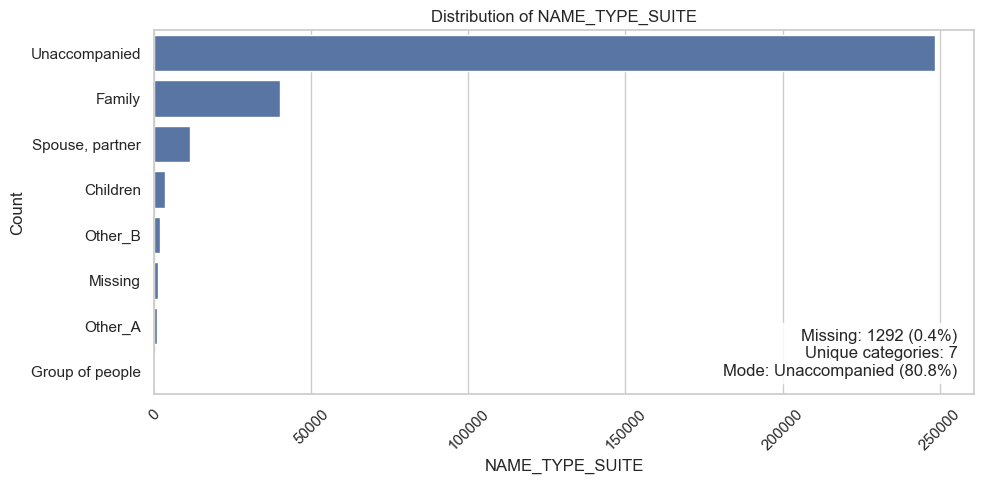

In [32]:
plot_categorical_distribution(df=app_df, cat_var='NAME_TYPE_SUITE')

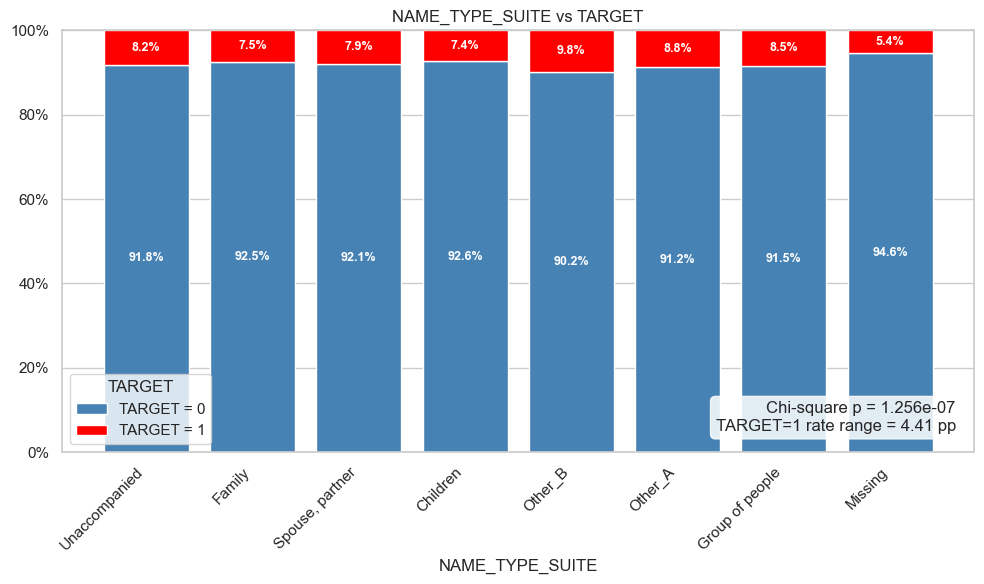

In [33]:
plot_categorical_vs_binary(df=app_df, cat_var='NAME_TYPE_SUITE', target_var='TARGET')

In [34]:
app_df['NAME_TYPE_SUITE_GROUPED'] = np.where(
    app_df['NAME_TYPE_SUITE'].isin(['Children', 'Other_B', 'Other_A', 'Group of people']),
    'Other',
    app_df['NAME_TYPE_SUITE']
)
app_df['NAME_TYPE_SUITE_GROUPED'].value_counts()

NAME_TYPE_SUITE_GROUPED
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Other                6174
Name: count, dtype: int64

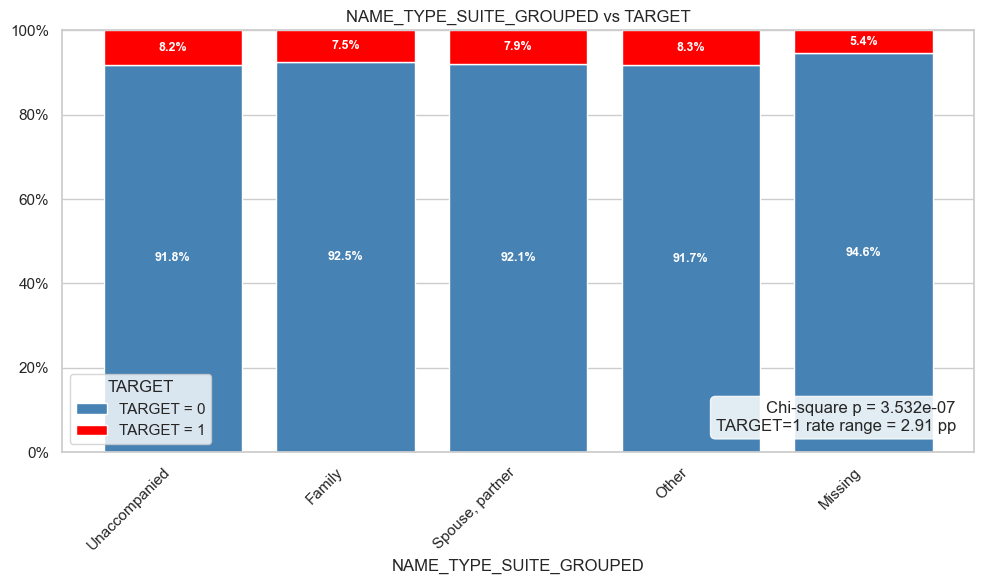

In [35]:
plot_categorical_vs_binary(df=app_df, cat_var='NAME_TYPE_SUITE_GROUPED', target_var='TARGET')

There are small differences between categories, only `Missing` shows significantly lower number of `TARGET = 1`.
We can add binary variable `NAME_TYPE_SUITE_MISSING`

## 2. DAYS_ID_PUBLISH
How many days before the application did client change the identity document with which he applied for the loan, time only

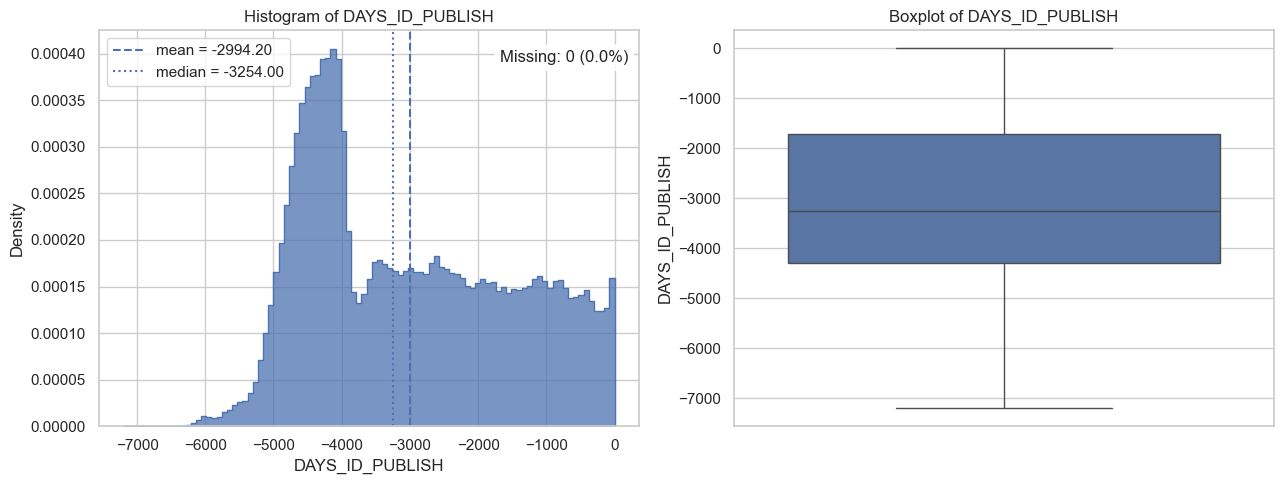

In [36]:
plot_quantitative_distribution(df=app_df, quant_var='DAYS_ID_PUBLISH')

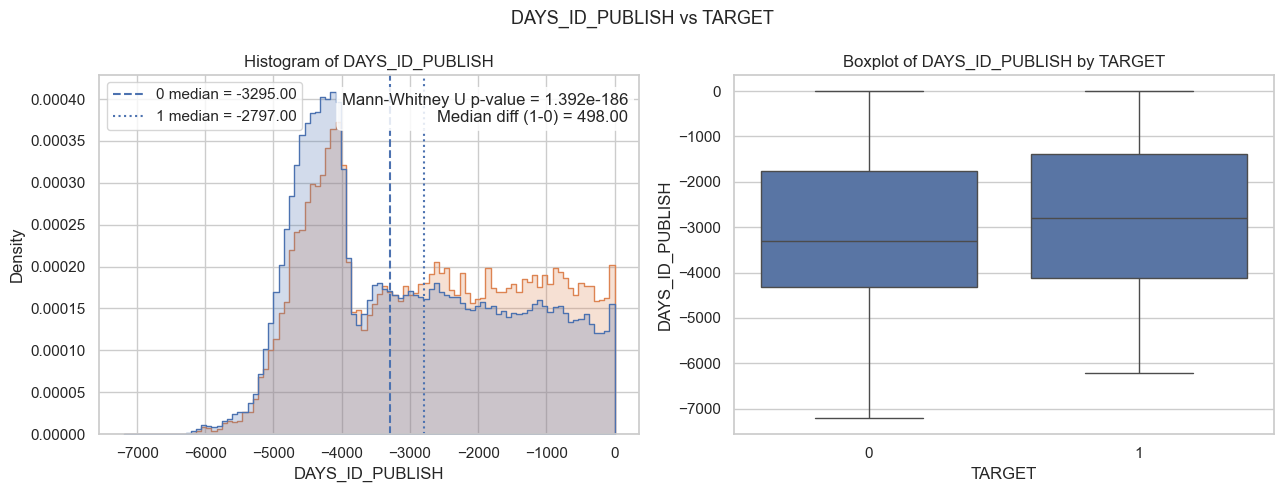

In [37]:
plot_quantitative_vs_binary(df=app_df, quant_var='DAYS_ID_PUBLISH', binary_var='TARGET')

Clients who defaulted changed their document with witch they applied for a loan signifianlty earlier. <br>
This variable propably hold important information for our modeling.

## 3. DAYS_EMPLOYED
How many days before the application the person started current employment,time only relative to the application

In [38]:
app_df['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

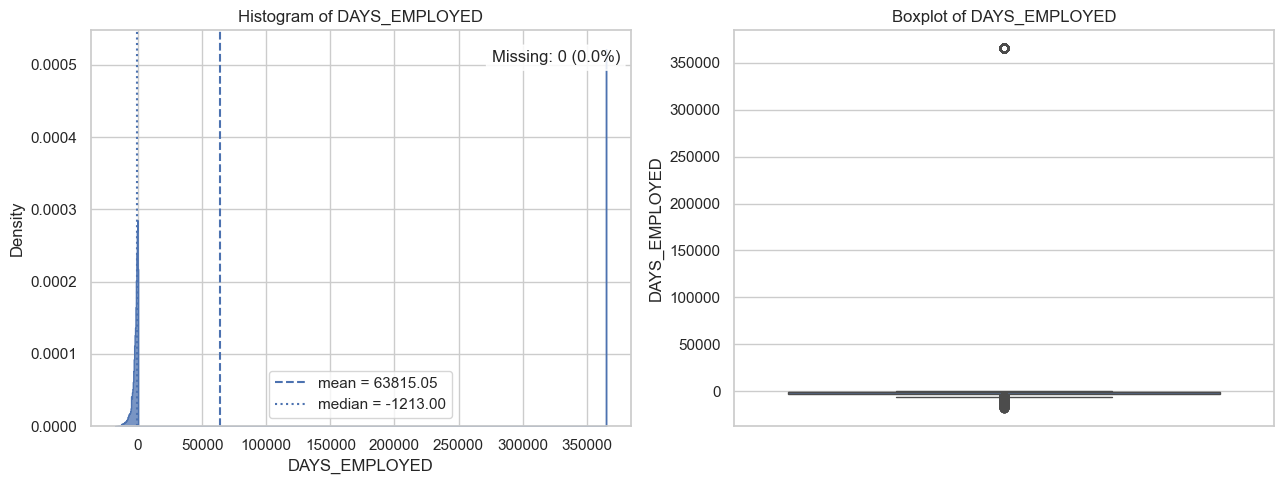

In [39]:
plot_quantitative_distribution(df=app_df, quant_var='DAYS_EMPLOYED')

In [40]:
app_df.loc[app_df['DAYS_EMPLOYED'] == 365243.000000].shape

(55374, 123)

In [41]:
app_df.loc[app_df['DAYS_EMPLOYED'] > 0].shape

(55374, 123)

In [42]:
round(app_df.loc[app_df['DAYS_EMPLOYED'] > 0].shape[0] / len(app_df),4)

0.1801

55374 observations have `DAYS_EMPLOYED` = 365243, which translates into over 1000 years, other than that this variable has rather values < 0.

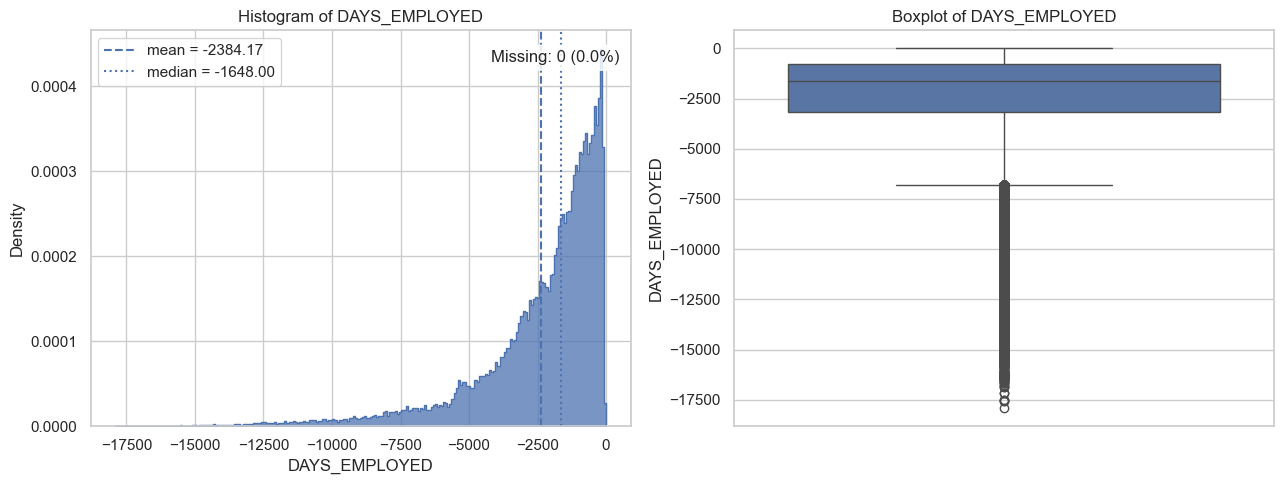

In [43]:
plot_quantitative_distribution(df=app_df.loc[app_df['DAYS_EMPLOYED']< 365243], quant_var='DAYS_EMPLOYED')

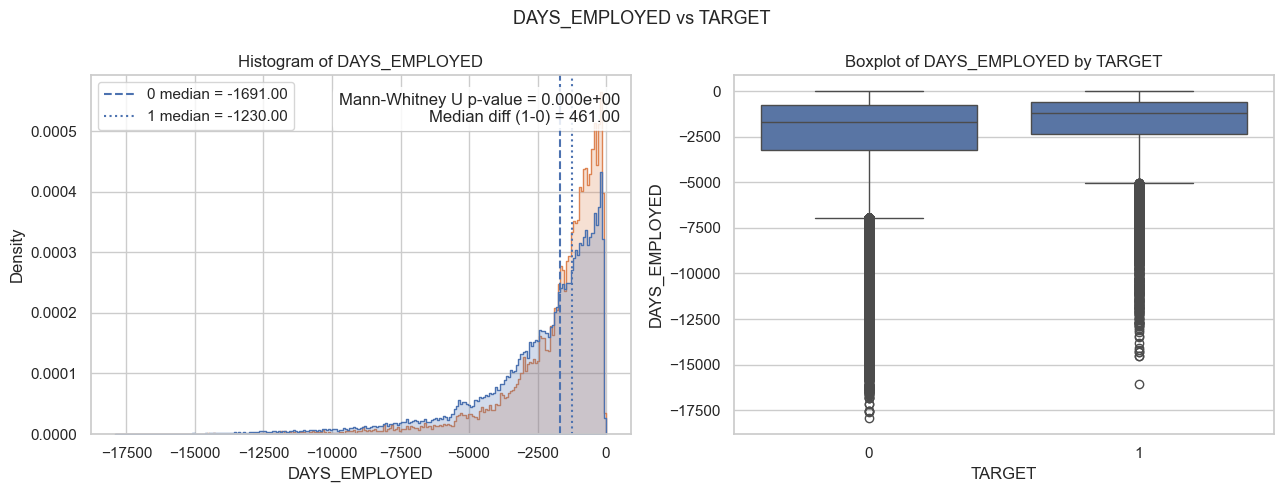

In [44]:
plot_quantitative_vs_binary(df=app_df.loc[app_df['DAYS_EMPLOYED']< 365243], quant_var='DAYS_EMPLOYED', binary_var='TARGET')

There is statistically significant difference between distributions, `DAYS_EMPLOYEED` might me considered as predictor. <br>
We will also check if the invalid values also affect the `TARGET`

In [45]:
app_df['DAYS_EMPLOYED_INVALID'] = np.where(
    app_df['DAYS_EMPLOYED'] > 0,
    1,
    0
)
app_df['DAYS_EMPLOYED_INVALID'].value_counts()

DAYS_EMPLOYED_INVALID
0    252137
1     55374
Name: count, dtype: int64

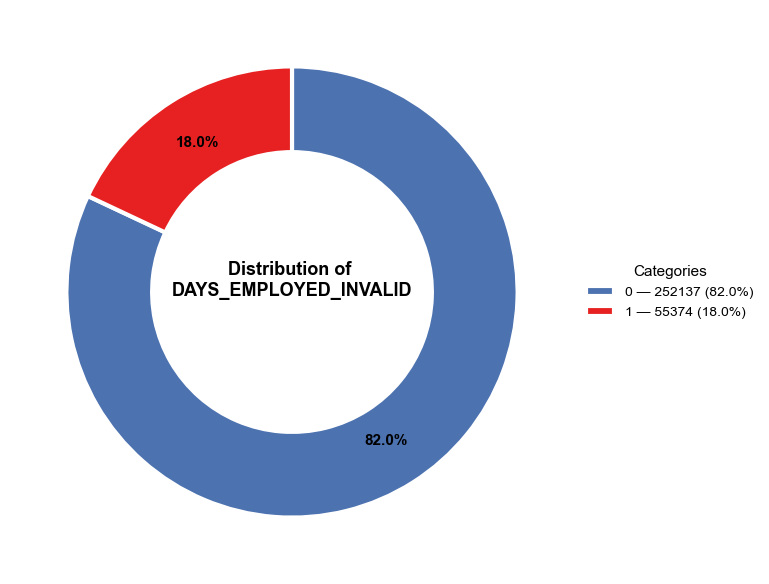

In [46]:
plot_binary_distribution(df=app_df, binary_var='DAYS_EMPLOYED_INVALID')

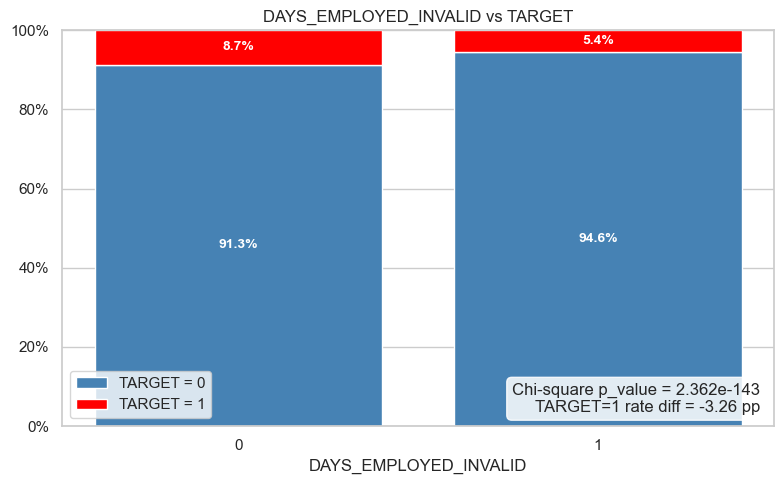

In [47]:
plot_binary_vs_binary(df=app_df, binary_var='DAYS_EMPLOYED_INVALID', target_var='TARGET')

There is small, but significant difference in distributions.
The invalid values will be imputed with the median

In [48]:
app_df['DAYS_EMPLOYED_IMPUTED_GLOBAL'] = np.where(
    app_df['DAYS_EMPLOYED'] > 0,
    app_df['DAYS_EMPLOYED'].median(),
    app_df['DAYS_EMPLOYED']
)
app_df['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

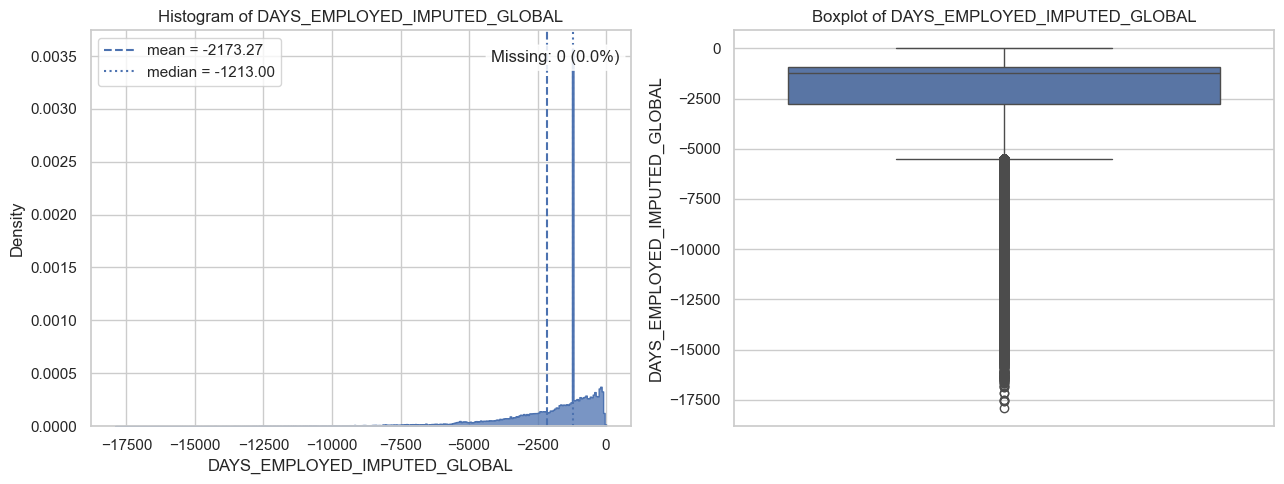

In [51]:
plot_quantitative_distribution(df=app_df, quant_var='DAYS_EMPLOYED_IMPUTED_GLOBAL')

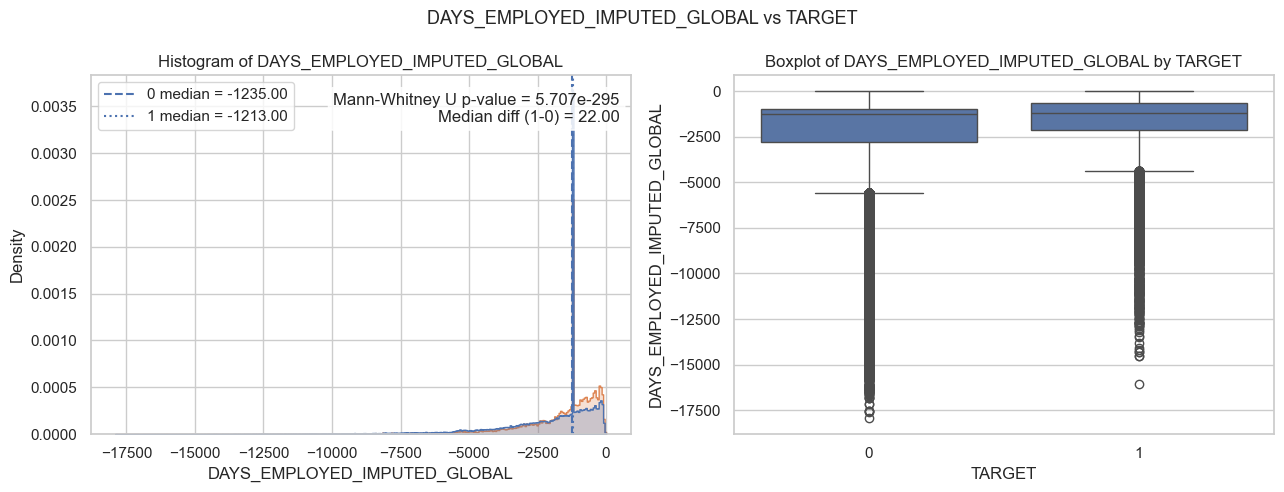

In [52]:
plot_quantitative_vs_binary(df=app_df, quant_var='DAYS_EMPLOYED_IMPUTED_GLOBAL', binary_var='TARGET')

Imputing such variable with global median results in washing up the previous signal by afrificially pulling big number of observations to one value.
We will consider:
- imputation with medians for different groups for other variables (`INCOME_TYPE`)
- leaving it with extreme value (`365243`) for tree based models

## 8. Application process summary
Variables that should be used as predictors
- `NAME_TYPE_SUITE_MISSING`
- `DAYS_ID_PUBLISH`
- `DAYS_EMPLOYED_IMPUTED` / `DAYS_EMPLOYED` (tree-based)
- `DAYS_EMPLOYED_INVALID`